In [12]:
# here we are implementing long-term memory in step-by-step learning pattern. (using RAM storage.) 

# Chatbot reading existing memories

In [13]:
# here we will give chatbot some memories and see how it responds with it..

In [14]:
from dotenv import load_dotenv
load_dotenv()

from langchain_groq import ChatGroq
from langchain_core.runnables import RunnableConfig
from langchain_core.messages import SystemMessage,HumanMessage

from langgraph.graph import StateGraph, START, END, MessagesState
from langgraph.store.memory import InMemoryStore
from langgraph.store.base import BaseStore

In [15]:
# 1. create LTM store and add some memories..

store = InMemoryStore()

user_id = "u1"

user_details = ("user",user_id,"details")
store.put(user_details,"profile_1",{"data":"name: Aditya"})
store.put(user_details,"profile_2",{"data":"profession: AIML student"})
store.put(user_details,"preference_1",{"data":"user prefer concise answer"})
store.put(user_details,"preference_2",{"data":"user prefers example in python."})
store.put(user_details,"project_1",{"data":"DocuMind- A RAG based chatbot for students."})

In [16]:
# 2. system prompt template..

SYSTEM_PROMPT_TEMPLATE = """You are a helpful assistant with memory capabilities.
If user-specific memory is available, use it to personalize 
your responses based on what you know about the user.

Your goal is to provide relevant, friendly, and tailored 
assistance that reflects the user’s preferences, context, and past interactions.

If the user’s name or relevant personal context is available, always personalize your responses by:
    – Always Address the user by name (e.g., "Sure, Nitish...") when appropriate
    – Referencing known projects, tools, or preferences (e.g., "your MCP  server python based project")
    – Adjusting the tone to feel friendly, natural, and directly aimed at the user

Avoid generic phrasing when personalization is possible. For example, instead of "In TypeScript apps..." 
say "Since your project is built with TypeScript..."

Use personalization especially in:
    – Greetings and transitions
    – Help or guidance tailored to tools and frameworks the user uses
    – Follow-up messages that continue from past context

Always ensure that personalization is based only on known user details and not assumed.

In the end suggest 3 relevant further questions based on the current response and user profile

The user’s memory (which may be empty) is provided as: {user_details_content}
"""

In [17]:
# 3. build graph: START -> chat -> END (read-only LTM)

LLM = ChatGroq(model="llama-3.3-70b-versatile", temperature=0)

In [18]:
def chat_node(state:MessagesState, config:RunnableConfig, store:BaseStore):

    user_id = config["configurable"]["user_id"]

    # only fetch user's details - no writes (for now..)
    user_details = ("user",user_id,"details") # same as above..
    items = store.search(user_details)

    # create memory items into a string bolb for {user_details_content}
    if items:
        user_details_content = "\n".join(f"- {item.value.get("data","")}" for item in items)
    else:
        user_details_content = "" # it can be empty.. as mentioned in prompt..

    system_prompt = SYSTEM_PROMPT_TEMPLATE.format(user_details_content = user_details_content)

    system_msg = SystemMessage(content=system_prompt)

    response = LLM.invoke([system_msg] + state["messages"])
    return {"messages":[response]}

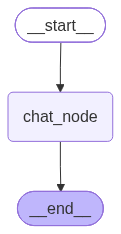

In [19]:
builder = StateGraph(MessagesState)

builder.add_node("chat_node",chat_node)

builder.add_edge(START,"chat_node")
builder.add_edge("chat_node",END)

graph = builder.compile(store=store)

graph

In [ ]:
# 4. Run 
config = {"configurable":{"user_id":"u1"}}

result = graph.invoke({"messages":[HumanMessage(content="explain gen ai in simple words")]},config=config)

result

{'messages': [HumanMessage(content='explain gen ai in simple words', additional_kwargs={}, response_metadata={}, id='e8c26649-7e08-4e29-97a9-8b16468228f0'),
  AIMessage(content='Hi Aditya, as an AIML student, you\'re likely familiar with AI concepts. Generative AI (Gen AI) is a type of AI that can create new content, like text, images, or music, on its own. It\'s like a very smart computer program that can generate new things based on what it has learned from existing data.\n\nThink of it like this: Imagine you\'re using a language model like the one in DocuMind, your RAG-based chatbot for students. If you ask it to write a short story, a Gen AI model can generate a brand new story, complete with characters, plot, and setting, all based on its understanding of what makes a good story.\n\nHere\'s a simple example in Python using the Hugging Face Transformers library:\n```python\nfrom transformers import T5Tokenizer, T5ForConditionalGeneration\n\n# Initialize the model and tokenizer\nmod

In [23]:
print(result["messages"][-1].content)

Hi Aditya, as an AIML student, you're likely familiar with AI concepts. Generative AI (Gen AI) is a type of AI that can create new content, like text, images, or music, on its own. It's like a very smart computer program that can generate new things based on what it has learned from existing data.

Think of it like this: Imagine you're using a language model like the one in DocuMind, your RAG-based chatbot for students. If you ask it to write a short story, a Gen AI model can generate a brand new story, complete with characters, plot, and setting, all based on its understanding of what makes a good story.

Here's a simple example in Python using the Hugging Face Transformers library:
```python
from transformers import T5Tokenizer, T5ForConditionalGeneration

# Initialize the model and tokenizer
model = T5ForConditionalGeneration.from_pretrained('t5-small')
tokenizer = T5Tokenizer.from_pretrained('t5-small')

# Define a prompt
prompt = "Write a short story about a student who learns AI"

In [24]:
result = graph.invoke({"messages":[HumanMessage(content="ok shortly explain RAG")]},config=config)
print(result["messages"][-1].content)

Hi Aditya, as an AIML student, you're likely interested in RAG (Retrieve, Augment, Generate) - a framework for building chatbots like DocuMind. 

RAG works as follows:
1. **Retrieve**: Fetch relevant information from a database or knowledge graph.
2. **Augment**: Expand or refine the retrieved information to better answer the user's question.
3. **Generate**: Use the augmented information to generate a response.

Here's a simple Python example:
```python
def retrieve(question):
    # Simulate retrieving information from a database
    return {"answer": "RAG is a chatbot framework"}

def augment(retrieved_info, question):
    # Simulate expanding the retrieved information
    retrieved_info["example"] = "DocuMind uses RAG"
    return retrieved_info

def generate(augmented_info):
    # Simulate generating a response
    return f"RAG is a chatbot framework. For example, {augmented_info['example']}"

print(generate(augment(retrieve("What is RAG?"), "What is RAG?")))
```
Next, you might wan

# Chatbot Creating new memories

In [92]:
# now we will see how we can make our chatbot able to create new memories.

In [93]:
from dotenv import load_dotenv
load_dotenv()

import uuid
from typing import List
from pydantic import BaseModel, Field

from langchain_groq import ChatGroq
from langchain_core.messages import SystemMessage, HumanMessage, AIMessage

from langgraph.graph import StateGraph, START, END, MessagesState
from langgraph.store.memory import InMemoryStore
from langgraph.store.base import BaseStore

In [94]:
extractor_llm = ChatGroq(model="llama-3.3-70b-versatile", temperature=0)

In [95]:
# store
store = InMemoryStore()

In [96]:
# schema for structured output..
class MemoryDecision(BaseModel):
    should_write: bool = Field(description="Whether to store any memories")
    memories: List[str] = Field(default_factory=list,description="Atomic user memories to store")

In [97]:
# llm with structured output
memory_extractor = extractor_llm.with_structured_output(MemoryDecision)

In [98]:
# Graph: START -> create_memories -> END (here we are just creating them and not using yet..)
def remember_only_node(state:MessagesState, config:RunnableConfig, store:BaseStore):

    user_id = config["configurable"]["user_id"]

    namespace = ("user",user_id,"details")

    # take last message
    last_msg = state["messages"][-1]

    # LLM decide what to store.
    decision: MemoryDecision = memory_extractor.invoke([
        SystemMessage(
            content=(
                    "Extract LONG-TERM memories from the user's message.\n"
                    "Only store stable, user-specific info (identity, preferences, ongoing projects).\n"
                    "Do NOT store transient info.\n"
                    "Return should_write=false if nothing is worth storing.\n"
                    "Each memory should be a short atomic sentence."
            )
        ),
        last_msg
    ])

    # write to store i,e LTM
    if decision.should_write:
        for mem in decision.memories:
            store.put(namespace,str(uuid.uuid4()),{"data":mem})

    return {"messages":[AIMessage(content="Noted.")]}

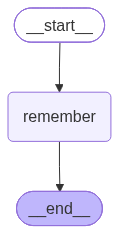

In [99]:
builder = StateGraph(MessagesState)

builder.add_node("remember",remember_only_node)

builder.add_edge(START,"remember")
builder.add_edge("remember",END)

graph = builder.compile(store=store)

graph

In [100]:
config = {"configurable":{"user_id":"u1"}}

res = graph.invoke({"messages": [HumanMessage(content="Hi, my name is Aditya")]},config)
print("Assistant:", res["messages"][-1].content)

Assistant: Noted.


In [101]:
res = graph.invoke({"messages": [HumanMessage(content="i am AIML student")]},config)
print("Assistant:", res["messages"][-1].content)

Assistant: Noted.


In [102]:
res = graph.invoke({"messages": [HumanMessage(content="i have created 2 major projects")]},config)
print("Assistant:", res["messages"][-1].content)

Assistant: Noted.


In [103]:
res = graph.invoke({"messages": [HumanMessage(content="what is LLM?")]},config)
print("Assistant:", res["messages"][-1].content)

Assistant: Noted.


In [104]:
items = store.search(("user","u1","details"))

for item in items:
    print(item.value["data"])

My name is Aditya
The user is an AIML student
The user has created 2 major projects


In [105]:
# ok so memories are created but problem is if u re-run the same info again.
# the same memories will be re-written again.

In [106]:
res = graph.invoke({"messages": [HumanMessage(content="Hi, my name is Aditya")]},config)
print("Assistant:", res["messages"][-1].content)

res = graph.invoke({"messages": [HumanMessage(content="i am AIML student")]},config)
print("Assistant:", res["messages"][-1].content)

res = graph.invoke({"messages": [HumanMessage(content="i have created 2 major projects")]},config)
print("Assistant:", res["messages"][-1].content)

res = graph.invoke({"messages": [HumanMessage(content="what is LLM?")]},config)
print("Assistant:", res["messages"][-1].content)

items = store.search(("user","u1","details"))

for item in items:
    print(item.value["data"])

Assistant: Noted.
Assistant: Noted.
Assistant: Noted.
Assistant: Noted.
My name is Aditya
The user is an AIML student
The user has created 2 major projects
My name is Aditya
The user is an AIML student
The user has created 2 major projects


# Chatbot creating new memories (without duplication)

In [107]:

# here we will overcome this duplication problem

In [108]:
from dotenv import load_dotenv
load_dotenv()

import uuid
from typing import List
from pydantic import BaseModel, Field

from langchain_groq import ChatGroq
from langchain_core.messages import HumanMessage, SystemMessage, AIMessage

from langgraph.graph import StateGraph, START, END, MessagesState
from langgraph.store.memory import InMemoryStore
from langgraph.store.base import BaseStore

In [109]:
extractor_llm = ChatGroq(model="llama-3.3-70b-versatile", temperature=0)

In [110]:
# store
store = InMemoryStore()

In [111]:
# schema to decide wheather the memory is duplicate or unique
class MemoryItem(BaseModel):
    text: str = Field(description="Atomic user memory as a short sentence")
    is_new: bool = Field(description="True if this memory is NEW and should be stored. False if duplicate/already known.")

In [112]:
# schema for structured output.
class MemoryDecision(BaseModel):
    should_write: bool = Field(description="Whether to store any memorie")
    memories: List[MemoryItem] = Field(default_factory=list, description="Atomic user memories to store")

In [113]:
# LLM with structured output
memory_extractor = extractor_llm.with_structured_output(MemoryDecision)

In [114]:
MEMORY_PROMPT = """You are responsible for updating and maintaining accurate user memory.

CURRENT USER DETAILS (existing memories):
{user_details_content}

TASK:
- Review the user's latest message.
- Extract user-specific info worth storing long-term (identity, stable preferences, ongoing projects/goals).
- For each extracted item, set is_new=true ONLY if it adds NEW information compared to CURRENT USER DETAILS.
- If it is basically the same meaning as something already present, set is_new=false.
- Keep each memory as a short atomic sentence.
- No speculation; only facts stated by the user.
- If there is nothing memory-worthy, return an empty list.
"""

In [115]:
def remember_memory_node(state:MessagesState, config:RunnableConfig, store:BaseStore):

    user_id = config["configurable"]["user_id"]

    namespace = ("user",user_id,"details")

    # 1. Load existing memory
    existing_items = store.search(namespace)
    existing_texts = [{item.value.get("data","")} for item in existing_items if item.value.get("data")]
    user_details_content = "\n".join(f"- {text}" for text in existing_texts) if existing_texts else "(empty)"

    # 2. last user message
    last_text = state["messages"][-1]

    # 3. LLM extacts memories + marks unique/duplicate...
    decision: MemoryDecision = memory_extractor.invoke([
        SystemMessage(content= MEMORY_PROMPT.format(user_details_content = user_details_content)),
        last_text
    ])

    # 4. store only new memories..
    if decision.should_write:
        for mem in decision.memories:
            if mem.is_new:
                store.put(namespace,str(uuid.uuid4()),{"data":mem.text})

    return {"messages":[AIMessage(content="Noted.")]}

In [116]:
builder = StateGraph(MessagesState)

builder.add_node("remember",remember_memory_node)

builder.add_edge(START,"remember")
builder.add_edge("remember",END)

graph = builder.compile(store=store)

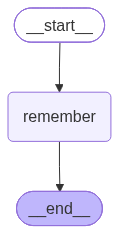

In [117]:
graph

In [118]:
config = {"configurable":{"user_id":"u2"}}

In [123]:
res = graph.invoke({"messages": [HumanMessage(content="Hi, my name is Aditya")]},config)
print("Assistant:", res["messages"][-1].content)

res = graph.invoke({"messages": [HumanMessage(content="i am AIML student")]},config)
print("Assistant:", res["messages"][-1].content)

res = graph.invoke({"messages": [HumanMessage(content="i have created 2 major projects")]},config)
print("Assistant:", res["messages"][-1].content)

res = graph.invoke({"messages": [HumanMessage(content="what is LLM?")]},config)
print("Assistant:", res["messages"][-1].content)

Assistant: Noted.
Assistant: Noted.
Assistant: Noted.
Assistant: Noted.


In [124]:
items = store.search(("user","u2","details"))

for item in items:
    print(item.value["data"])

My name is Aditya
I am an AIML student
I have created 2 major projects


# Merged Workflow

In [1]:
# here we are merging both memory retrival + memory creation to implement a perfect LTM.

In [60]:
from dotenv import load_dotenv
load_dotenv()

import uuid
from langchain_groq import ChatGroq
from typing import List
from pydantic import BaseModel, Field

from langgraph.graph import StateGraph, START, END, MessagesState
from langchain_core.messages import SystemMessage, HumanMessage

from langgraph.store.memory import InMemoryStore
from langgraph.config import RunnableConfig
from langgraph.store.base import BaseStore

In [61]:
store = InMemoryStore()

In [62]:
SYSTEM_PROMPT_TEMPLATE = """You are a helpful assistant with memory capabilities.
If user-specific memory is available, use it to personalize 
your responses based on what you know about the user.

Your goal is to provide relevant, friendly, and tailored 
assistance that reflects the user’s preferences, context, and past interactions.

If the user’s name or relevant personal context is available, always personalize your responses by:
    – Always Address the user by name (e.g., "Sure, Nitish...") when appropriate
    – Referencing known projects, tools, or preferences (e.g., "your MCP  server python based project")
    – Adjusting the tone to feel friendly, natural, and directly aimed at the user

Avoid generic ph"rasing when personalization is possible. For example, instead of "In TypeScript apps..." 
say "Since your project is built with TypeScript..."

Use personalization especially in:
    – Greetings and transitions
    – Help or guidance tailored to tools and frameworks the user uses
    – Follow-up messages that continue from past context

Always ensure that personalization is based only on known user details and not assumed.

In the end suggest 3 relevant further questions based on the current response and user profile

The user’s memory (which may be empty) is provided as: {user_details_content}
"""

In [63]:
# define schemas 
class MemoryItem(BaseModel):
    text: str = Field(description="Atomic user memory as a short sentence")
    is_new: bool = Field(description="True if this memory is NEW and should be stored. False if duplicate/already known.")

class MemoryDecision(BaseModel):
    should_wirte: bool = Field(description="Whether to store any memorie")
    memories : List[MemoryItem] = Field(default_factory=list,description="Atomic user memories to store")

In [64]:
LLM = ChatGroq(model="llama-3.3-70b-versatile", temperature=0)

In [65]:
memory_extractor = LLM.with_structured_output(MemoryDecision)

In [66]:
MEMORY_PROMPT = """You are responsible for updating and maintaining accurate user memory.

CURRENT USER DETAILS (existing memories):
{user_details_content}

TASK:
- Review the user's latest message.
- Extract user-specific info worth storing long-term (identity, stable preferences, ongoing projects/goals).
- For each extracted item, set is_new=true ONLY if it adds NEW information compared to CURRENT USER DETAILS.
- If it is basically the same meaning as something already present, set is_new=false.
- Keep each memory as a short atomic sentence.
- No speculation; only facts stated by the user.
- If there is nothing memory-worthy, return an empty list.
"""

In [67]:
# remember node
def remember_node(state:MessagesState, config:RunnableConfig, store:BaseStore):

    user_id = config["configurable"]["user_id"]

    namespace = ("user",user_id,"details")

    # existing memory
    items = store.search(namespace)
    exisiting_memory = "\n".join(f"- {item.value["data"]}" for item in items) if items else "(empty)"

    # last message
    last_text = state["messages"][-1]

    decision: MemoryDecision = memory_extractor.invoke([
        SystemMessage(content=MEMORY_PROMPT.format(user_details_content = exisiting_memory)),
        last_text
    ])

    if decision.should_wirte:
        for mem in decision.memories:
            if mem.is_new:
                store.put(namespace,str(uuid.uuid4()),{"data":mem.text})


    return {} # no message exchange.

In [68]:
# chat node
def chat_node(state:MessagesState, config:RunnableConfig,*,store: BaseStore):

    user_id = config["configurable"]["user_id"]

    namespace = ("user",user_id,"details")

    items = store.search(namespace)
    user_details = "\n".join(item.value["data"] for item in items) if items else ""

    system_msg = SystemMessage(
        content=SYSTEM_PROMPT_TEMPLATE.format(
            user_details_content = user_details or "(empty)"
        )
    )

    response = LLM.invoke([system_msg] + state["messages"])

    return {"messages":[response]}

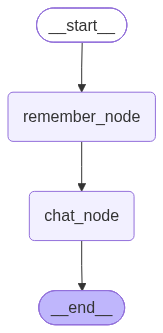

In [69]:
graph_builder = StateGraph(MessagesState)

graph_builder.add_node("remember_node",remember_node)
graph_builder.add_node("chat_node",chat_node)

graph_builder.add_edge(START,"remember_node")
graph_builder.add_edge("remember_node","chat_node")
graph_builder.add_edge("chat_node",END)

graph = graph_builder.compile(store=store)

graph

In [70]:
# Demo
config = {"configurable":{"user_id":"u1"}}

In [71]:
result = graph.invoke({"messages":[HumanMessage(content="hello, i am bob")]},config=config)
print(result["messages"][-1].content)

print("\n-----------\n")

for item in store.search(("user","u1","details")):
    print(item.value["data"])

Hello Bob, it's nice to meet you. I'll be happy to help you with any questions or topics you'd like to discuss. Since we're just getting started, I don't have any prior knowledge about your projects or preferences, but I'm excited to learn more about what you're working on and how I can assist you.

To get us started, is there something specific on your mind that you'd like to talk about, or would you like me to suggest some conversation topics?

Here are three potential questions to consider:
1. What kind of projects or hobbies have you been exploring lately, Bob?
2. Are you working with any specific programming languages or tools that I can help with?
3. Is there a particular challenge or problem you're trying to solve, and how can I help you find a solution?

-----------

I am Bob


In [72]:
result = graph.invoke({"messages":[HumanMessage(content="actually i am currently learning AIML")]},config=config)
print(result["messages"][-1].content)

print("\n-----------\n")

for item in store.search(("user","u1","details")):
    print(item.value["data"])

Nice to meet you, Bob. I see you're currently learning AIML, which is a great skill to have. AIML (Artificial Intelligence Markup Language) is a fantastic tool for creating conversational interfaces, and I'm happy to help you with any questions or topics you'd like to discuss related to it.

Since you're learning AIML, I'm assuming you're interested in natural language processing and chatbot development. Are you working on a specific project, or is this more of a general exploration of the technology?

To further assist you, I'd like to ask some follow-up questions:

1. What specific aspects of AIML are you finding most challenging or interesting so far, Bob?
2. Are you using any particular AIML tools or platforms, such as Program-O or AIMLBot, in your learning journey?
3. Do you have a specific goal in mind for your AIML skills, such as building a chatbot for a particular industry or application, Bob?

-----------

I am Bob
I am learning AIML


In [73]:
result = graph.invoke({"messages":[HumanMessage(content="not Artificial Intelligence Markup Language, Artificial Intelligence Machine Learning")]},config=config)
print(result["messages"][-1].content)

print("\n-----------\n")

for item in store.search(("user","u1","details")):
    print(item.value["data"])

Welcome back, Bob. I've updated your profile to reflect that you're learning Artificial Intelligence and Machine Learning. I'll make sure to provide personalized assistance based on your interests in AI and ML.

Since you're exploring the exciting world of Artificial Intelligence and Machine Learning, I'd be happy to help you navigate the various concepts, tools, and frameworks associated with these fields. Your journey in AI and ML will likely involve working with popular libraries, frameworks, and programming languages such as Python, TensorFlow, or PyTorch.

To further assist you, I'd like to ask some follow-up questions:

1. What specific areas of Artificial Intelligence and Machine Learning interest you the most, Bob, such as natural language processing, computer vision, or predictive modeling?
2. Are you working on any projects that involve AI or ML, or is there a particular problem you're trying to solve using these technologies?
3. Have you explored any specific tools or framew

In [74]:
result = graph.invoke({"messages":[HumanMessage(content="yea i am learning machine learning")]},config=config)
print(result["messages"][-1].content)

print("\n-----------\n")

for item in store.search(("user","u1","details")):
    print(item.value["data"])

Nice to catch up with you, Bob. It's great to hear that you're making progress with Machine Learning. Since you're learning Artificial Intelligence and Machine Learning, I'm sure you're finding it fascinating to explore the various aspects of ML, such as supervised and unsupervised learning, neural networks, and deep learning.

As you dive deeper into ML, you might want to consider exploring some popular libraries and frameworks like TensorFlow, PyTorch, or Scikit-learn, which can help you implement ML algorithms and models. Your background in AIML will likely provide a solid foundation for understanding the concepts and techniques used in Machine Learning.

Here are three questions to further explore your interests and help me provide more tailored guidance:
1. What specific area of Machine Learning are you most interested in, such as computer vision, natural language processing, or predictive modeling?
2. Have you worked on any ML projects yet, or are you looking for ideas to get sta